In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import unary_union


In [5]:
FLOODS_FILE = "Recorded_Flood_Outlines.geojson"

LAD_BOUNDARIES_FILE = (
    "Local_Authority_Districts_December_2024_Boundaries_UK_BFC_-8514277369542505193.geojson"
)

LAD_AREAS_FILE = (
    "Standard_Area_Measurements_for_the_Local_Authority_Districts_"
    "(December_2024)_in_the_United_Kingdom.geojson"
)

TARGET_CRS = "EPSG:27700"
START_YEAR = 2010


In [6]:
print("Loading flood outlines...")
floods = gpd.read_file(FLOODS_FILE).to_crs(TARGET_CRS)

print("Loading LAD boundaries...")
lads = gpd.read_file(LAD_BOUNDARIES_FILE).to_crs(TARGET_CRS)

print("Loading LAD areas...")
lad_areas = gpd.read_file(LAD_AREAS_FILE)


Loading flood outlines...
Loading LAD boundaries...
Loading LAD areas...


In [7]:
# Merge authoritative areas into LAD boundaries
lads = lads.merge(
    lad_areas[["LAD24CD", "AREAEHECT"]],
    on="LAD24CD",
    how="left"
)

# Convert hectares → m²
lads["AREA_M2"] = lads["AREAEHECT"] * 10_000


In [8]:
print("Extracting years from flood dates...")

floods["year"] = pd.to_datetime(
    floods["start_date"], errors="coerce"
).dt.year

floods = floods[floods["year"] >= START_YEAR]

YEARS = sorted(floods["year"].dropna().unique())

print(f"Years analysed: {YEARS[0]}–{YEARS[-1]}")
print(f"Total LADs: {len(lads)}")


Extracting years from flood dates...
Years analysed: 2010.0–2025.0
Total LADs: 361


In [9]:
print("Building England geometry...")

england_lads = lads[lads["LAD24CD"].str.startswith("E")]
england_geom = unary_union(england_lads.geometry)

england_area = england_lads["AREA_M2"].sum()

print(f"England area (m²): {england_area:,.0f}")


Building England geometry...
England area (m²): 132,925,351,000


In [10]:
print("Fixing flood geometries...")
floods["geometry"] = floods.geometry.make_valid()

print("Building spatial index...")
_ = floods.sindex

print("Simplifying England geometry...")
england_geom = england_geom.simplify(5)
print("Caching England flooding by year...")
england_yearly_fraction = {}

for year in YEARS:

    floods_y = floods[floods["year"] == year]
    print(f"Year {year}: {len(floods_y)} flood polygons")
    flooded_geom = floods_y.geometry.intersection(england_geom)
    flooded_area = flooded_geom.area.sum()

    england_yearly_fraction[year] = flooded_area / england_area

print("England flooding cached.")


Fixing flood geometries...
Building spatial index...
Simplifying England geometry...
Caching England flooding by year...
Year 2010.0: 101 flood polygons
Year 2011.0: 64 flood polygons
Year 2012.0: 677 flood polygons
Year 2013.0: 234 flood polygons
Year 2014.0: 634 flood polygons
Year 2015.0: 852 flood polygons
Year 2016.0: 248 flood polygons
Year 2017.0: 265 flood polygons
Year 2018.0: 71 flood polygons
Year 2019.0: 271 flood polygons
Year 2020.0: 363 flood polygons
Year 2021.0: 123 flood polygons
Year 2022.0: 67 flood polygons
Year 2023.0: 676 flood polygons
Year 2024.0: 361 flood polygons
Year 2025.0: 246 flood polygons
England flooding cached.


In [11]:
results = []

for i, row in lads.iterrows():
    lad_name = row["LAD24NM"]
    lad_geom = row.geometry
    lad_area = row["AREA_M2"]

    if lad_geom is None or lad_geom.is_empty or lad_area == 0:
        continue

    yearly_fractions = []

    for year in YEARS:
        floods_y = floods[floods["year"] == year]

        flooded = floods_y.geometry.intersection(lad_geom)
        flooded_area = flooded.area.sum()

        yearly_fractions.append(flooded_area / lad_area)

    mean_fraction = np.mean(yearly_fractions)

    results.append({
        "LAD": lad_name,
        "mean_flood_fraction": mean_fraction
    })

    if (i + 1) % 25 == 0:
        print(f"Processed {i + 1} / {len(lads)} LADs")


Processed 25 / 361 LADs
Processed 50 / 361 LADs
Processed 75 / 361 LADs
Processed 100 / 361 LADs
Processed 125 / 361 LADs
Processed 150 / 361 LADs
Processed 175 / 361 LADs
Processed 200 / 361 LADs
Processed 225 / 361 LADs
Processed 250 / 361 LADs
Processed 275 / 361 LADs
Processed 300 / 361 LADs
Processed 325 / 361 LADs
Processed 350 / 361 LADs


In [12]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "mean_flood_fraction",
    ascending=False
).reset_index(drop=True)

results_df.head(10)


,LAD,mean_flood_fraction
0,Oxford,0.014470
1,Spelthorne,0.011970
2,Runnymede,0.009146
3,York,0.008230
4,Windsor and Maidenhead,0.007071
5,Doncaster,0.005302
6,Somerset,0.004957
7,Leeds,0.004675
8,Maidstone,0.004667
9,East Riding of Yorkshire,0.004661


In [13]:
def plot_lad_vs_england(lad_name):
    lad_row = lads[lads["LAD24NM"] == lad_name].iloc[0]
    lad_geom = lad_row.geometry
    lad_area = lad_row["AREA_M2"]

    lad_series = []

    for year in YEARS:
        floods_y = floods[floods["year"] == year]
        flooded = floods_y.geometry.intersection(lad_geom)
        lad_series.append(flooded.area.sum() / lad_area)

    england_series = [england_yearly_fraction[y] for y in YEARS]

    plt.figure(figsize=(10, 5))
    plt.plot(YEARS, lad_series, label=lad_name)
    plt.plot(YEARS, england_series, label="England", linestyle="--")
    plt.ylabel("Flooded fraction of area")
    plt.xlabel("Year")
    plt.legend()
    plt.title(f"Flooding per unit area: {lad_name} vs England")
    plt.tight_layout()
    plt.show()


In [27]:
def plot_lad_vs_england(lad_name):
    # --------------------------------------------------
    # Select LAD
    # --------------------------------------------------
    lad_row = lads[lads["LAD24NM"] == lad_name].iloc[0]
    lad_geom = lad_row.geometry
    lad_area = lad_row["AREA_M2"]

    # --------------------------------------------------
    # LAD yearly flooded fractions (zeros included)
    # --------------------------------------------------
    lad_series = []

    for year in YEARS:
        floods_y = floods[floods["year"] == year]

        flooded = floods_y.geometry.intersection(lad_geom)
        lad_fraction = flooded.area.sum() / lad_area

        lad_series.append(lad_fraction)

    # --------------------------------------------------
    # England yearly flooded fractions (cached)
    # --------------------------------------------------
    england_series = [england_yearly_fraction[y] for y in YEARS]

    # --------------------------------------------------
    # Mean values
    # --------------------------------------------------
    lad_mean = sum(lad_series) / len(lad_series)
    england_mean = sum(england_series) / len(england_series)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))

    plt.plot(YEARS, lad_series, label=lad_name)
    plt.plot(YEARS, england_series, label="England")

    # Mean lines
    plt.axhline(
        lad_mean,
        linestyle="--",
        linewidth=2,
        label=f"{lad_name} mean"
    )

    plt.axhline(
        england_mean,
        linestyle="--",
        linewidth=2,
        color="tab:orange",
        label="England mean"
    )

    plt.ylabel("Flooded fraction of area")
    plt.xlabel("Year")
    plt.title(f"Flooding per unit area: {lad_name} vs England", fontsize = 14)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: print means for clarity
    print(f"{lad_name} mean flooded fraction: {lad_mean:.6f}")
    print(f"England mean flooded fraction: {england_mean:.6f}")


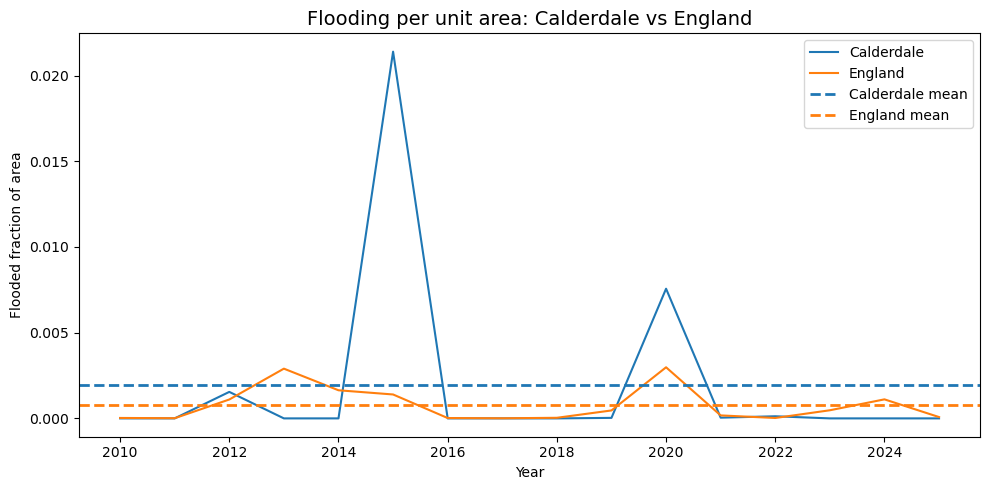

Calderdale mean flooded fraction: 0.001919
England mean flooded fraction: 0.000777


In [28]:
plot_lad_vs_england("Calderdale")


In [35]:
import matplotlib.pyplot as plt

def plot_lads_vs_england(lad_names):
    """
    Plot multiple LAD flooded fractions vs England,
    using consistent colours per LAD and standard
    Matplotlib palette. Mean lines are drawn only
    across the years where data exists (2010–2025).
    """

    # ---------------------------------------------
    # Get default matplotlib colour cycle
    # ---------------------------------------------
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    plt.figure(figsize=(10, 4))

    # ---------------------------------------------
    # England yearly flooded fractions (cached)
    # ---------------------------------------------
    england_series = [england_yearly_fraction[y] for y in YEARS]
    england_mean = sum(england_series) / len(england_series)

    # ---------------------------------------------
    # Loop through LADs
    # ---------------------------------------------
    for i, lad_name in enumerate(lad_names):

        color = colors[i % len(colors)]  # cycle palette

        # Select LAD
        lad_row = lads[lads["LAD24NM"] == lad_name].iloc[0]
        lad_geom = lad_row.geometry
        lad_area = lad_row["AREA_M2"]

        # Yearly flooded fractions
        lad_series = []

        for year in YEARS:
            floods_y = floods[floods["year"] == year]

            flooded = floods_y.geometry.intersection(lad_geom)
            lad_fraction = flooded.area.sum() / lad_area

            lad_series.append(lad_fraction)

        # Mean
        lad_mean = sum(lad_series) / len(lad_series)

        # Plot LAD yearly line
        plt.plot(
            YEARS,
            lad_series,
            color=color,
            linewidth=2,
            label=lad_name
        )

        # Plot LAD mean only across actual data years
        plt.plot(
            YEARS,
            [lad_mean] * len(YEARS),
            linestyle="--",
            linewidth=2,
            color=color,
            label=f"{lad_name} mean"
        )

        print(f"{lad_name} mean flooded fraction: {lad_mean:.6f}")

    # ---------------------------------------------
    # England colour (next in palette)
    # ---------------------------------------------
    england_color = colors[len(lad_names) % len(colors)]

    plt.plot(
        YEARS,
        england_series,
        color=england_color,
        linewidth=2,
        label="England"
    )

    # England mean only across actual data years
    plt.plot(
        YEARS,
        [england_mean] * len(YEARS),
        linestyle="--",
        linewidth=2,
        color=england_color,
        label="England mean"
    )

    print(f"England mean flooded fraction: {england_mean:.6f}")

    # ---------------------------------------------
    # Formatting
    # ---------------------------------------------
    plt.ylabel("Flooded fraction of area", fontsize = 11)
    plt.xlabel("Year", fontsize = 11)
    plt.title("Fraction of Areas that Experience any Flooding by Year", fontsize =13)
    plt.legend()
    plt.tight_layout()
    plt.savefig("flooding_fraction_comparison.png")
    plt.show()


West Lindsey mean flooded fraction: 0.002731
Calderdale mean flooded fraction: 0.001919
England mean flooded fraction: 0.000777


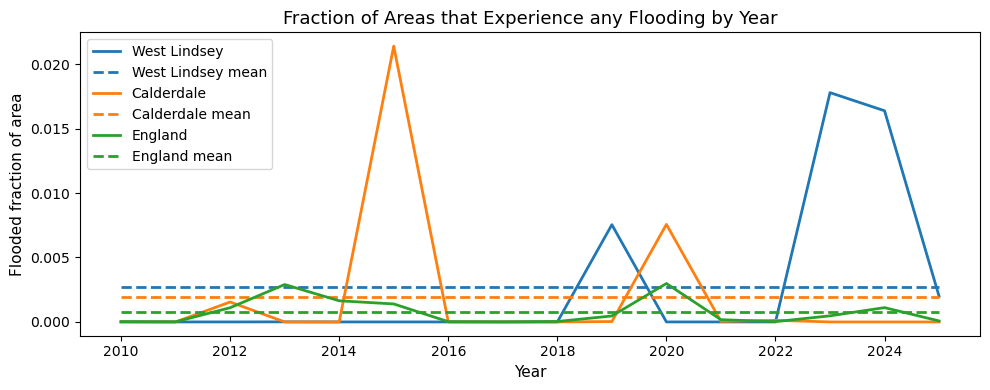

In [36]:
plot_lads_vs_england(["West Lindsey","Calderdale"])


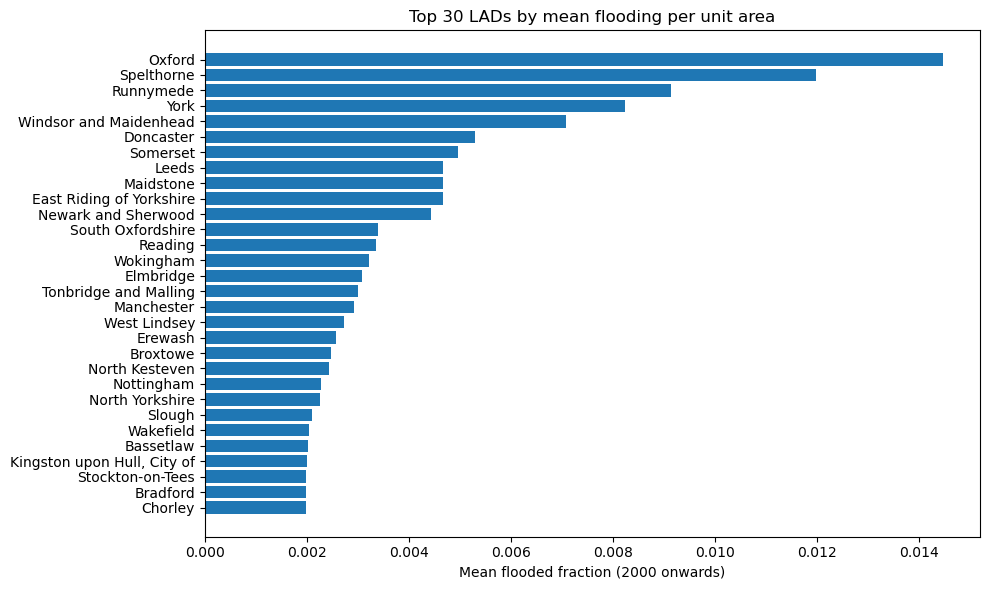

In [40]:
top30 = results_df.head(30)

plt.figure(figsize=(10, 6))
plt.barh(top30["LAD"], top30["mean_flood_fraction"])
plt.gca().invert_yaxis()
plt.xlabel("Mean flooded fraction (2000 onwards)")
plt.title("Top 30 LADs by mean flooding per unit area")
plt.tight_layout()
plt.show()
